# LeetCode #188: Best Time to Buy and Sell Stock IV

https://leetcode.com/problems/best-time-to-buy-and-sell-stock-iv/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| DP with k transactions ★ | O(nk) | O(k) |
| DP 2D table | O(nk) | O(nk) |

## Understanding the Methods
### DP with k Transactions (Optimal)
Track two states per transaction: the best profit after buying (holding stock) and after selling. For each day, update each transaction level. When k >= n/2, unlimited transactions are allowed so we use the greedy approach (sum all positive diffs).

### DP 2D Table
Use a 2D array dp[t][d] for t transactions and d days. Each cell tracks the max profit using at most t transactions up to day d. The space-optimized version reduces to O(k) by only keeping current buy/sell states.

## Solutions

### C#

In [ ]:
public class Solution {
    public int MaxProfit(int k, int[] prices) {
        int n = prices.Length;
        if (n == 0) return 0;
        
        // If k >= n/2, unlimited transactions
        if (k >= n / 2) {
            int profit = 0;
            for (int i = 1; i < n; i++) {
                if (prices[i] > prices[i - 1])
                    profit += prices[i] - prices[i - 1];
            }
            return profit;
        }
        
        int[] buy = new int[k + 1];
        int[] sell = new int[k + 1];
        Array.Fill(buy, int.MinValue);
        
        for (int i = 0; i < n; i++) {
            for (int j = 1; j <= k; j++) {
                buy[j] = Math.Max(buy[j], sell[j - 1] - prices[i]);
                sell[j] = Math.Max(sell[j], buy[j] + prices[i]);
            }
        }
        return sell[k];
    }
}

### Python

In [ ]:
class Solution:
    def maxProfit(self, k: int, prices: list[int]) -> int:
        n = len(prices)
        if n == 0:
            return 0
        
        # Unlimited transactions when k >= n/2
        if k >= n // 2:
            return sum(max(0, prices[i] - prices[i-1]) for i in range(1, n))
        
        buy = [float('-inf')] * (k + 1)
        sell = [0] * (k + 1)
        
        for price in prices:
            for j in range(1, k + 1):
                buy[j] = max(buy[j], sell[j-1] - price)
                sell[j] = max(sell[j], buy[j] + price)
        
        return sell[k]

### Go

In [ ]:
package main

import "math"

func maxProfit(k int, prices []int) int {
    n := len(prices)
    if n == 0 {
        return 0
    }
    if k >= n/2 {
        profit := 0
        for i := 1; i < n; i++ {
            if prices[i] > prices[i-1] {
                profit += prices[i] - prices[i-1]
            }
        }
        return profit
    }
    buy := make([]int, k+1)
    sell := make([]int, k+1)
    for i := range buy {
        buy[i] = math.MinInt32
    }
    for i := 0; i < n; i++ {
        for j := 1; j <= k; j++ {
            if sell[j-1]-prices[i] > buy[j] {
                buy[j] = sell[j-1] - prices[i]
            }
            if buy[j]+prices[i] > sell[j] {
                sell[j] = buy[j] + prices[i]
            }
        }
    }
    return sell[k]
}

### Rust

In [ ]:
pub struct Solution;

impl Solution {
    pub fn max_profit(k: i32, prices: Vec<i32>) -> i32 {
        let n = prices.len();
        let k = k as usize;
        if n == 0 {
            return 0;
        }
        if k >= n / 2 {
            return prices.windows(2)
                .map(|w| (w[1] - w[0]).max(0))
                .sum();
        }
        let mut buy = vec![i32::MIN; k + 1];
        let mut sell = vec![0; k + 1];
        for &price in &prices {
            for j in 1..=k {
                buy[j] = buy[j].max(sell[j - 1] - price);
                sell[j] = sell[j].max(buy[j] + price);
            }
        }
        sell[k]
    }
}

fn main() {
    println!("{}", Solution::max_profit(2, vec![3,2,6,5,0,3])); // 7
}

## Example Scenarios

### 1. Common Case — Two Profitable Transactions

**Input:** `k = 2, prices = [3, 2, 6, 5, 0, 3]`

Transaction 1: buy at 2, sell at 6 (+4). Transaction 2: buy at 0, sell at 3 (+3). Total profit = 7. The DP tracks `buy[j] = max(buy[j], sell[j-1] - price)` and `sell[j] = max(sell[j], buy[j] + price)` for each transaction level.

**WHY it's useful:** Standard DP walkthrough. Two arrays of size $k$ track the best profit after buying/selling at each transaction level. Time: $O(nk)$, Space: $O(k)$.

---

### 2. Slightly Complex — Fewer Transactions Than Allowed

**Input:** `k = 2, prices = [2, 4, 1]`

Only one profitable transaction exists: buy at 2, sell at 4 (+2). The second allowed transaction is unused — buying at 1 with no later sell is unprofitable. The DP naturally finds that `sell[2] = 2` (same as `sell[1]`).

**WHY it's tricky:** Having $k = 2$ doesn't mean both transactions must be used. The DP maximizes profit by choosing the optimal number of transactions ($\leq k$), not exactly $k$.

---

### 3. Edge Case: Time Factor — Large $k$ Triggers Greedy ($k \geq n/2$)

**Input:** `k = 50000, prices = [1, 2, 3, ..., 100000]` (ascending, $n = 100{,}000$)

Since $k \geq n/2$, switch to greedy: sum all positive daily differences. Result = $(2-1) + (3-2) + \cdots + (100000-99999) = 99{,}999$. Without this optimization, the DP would run $O(nk) = 5 \times 10^9$ operations — TLE.

**WHY it tests time:** The greedy shortcut is essential. When $k \geq n/2$, unlimited transactions are effectively allowed, so the DP reduces to a simple linear scan. Forgetting this optimization causes TLE.

---

### 4. Edge Case: Space Factor — Maximum $k$ Without Greedy Shortcut

**Input:** `k = 49999, prices = [1, 1000, 1, 1000, ...]` alternating ($n = 100{,}000$). Here $k < n/2$, so the greedy shortcut does not apply.

The 1D DP arrays `buy[k]` and `sell[k]` require $O(k) \approx 200$ KB each. A 2D table `dp[k][n]` would need $O(nk) \approx 20$ GB — completely infeasible.

**WHY it tests space:** $k$ just below the greedy threshold forces the full DP path. The 1D space optimization (two arrays of size $k$ instead of a 2D table) reduces memory from $O(nk)$ to $O(k)$ — a factor of $n$ savings.

---

### 5. Almost-Impossible — Zero Transactions and Empty Prices

**Input:** Case A: `k = 0, prices = [5, 10, 15]`. Case B: `k = 100, prices = []`. Case C: `k = 1, prices = [10, 9, 8, 7, 6]`.

Case A: $k = 0$ means the loop `for j in 1..k` is empty — `sell[0] = 0` always. Case B: $n = 0$ triggers early return. Case C: strictly decreasing prices — every buy-sell pair loses money, so `sell[1]` stays at 0. All three return 0.

**WHY it's extreme:** Tests three boundary conditions simultaneously: $k = 0$ (empty loop range), empty prices ($n = 0$ guard), and decreasing prices (no profitable trade). Initializing `buy[]` to $-\infty$ and `sell[]` to 0 is critical — if `sell[]` started at $-\infty$, Case A would return a negative number.

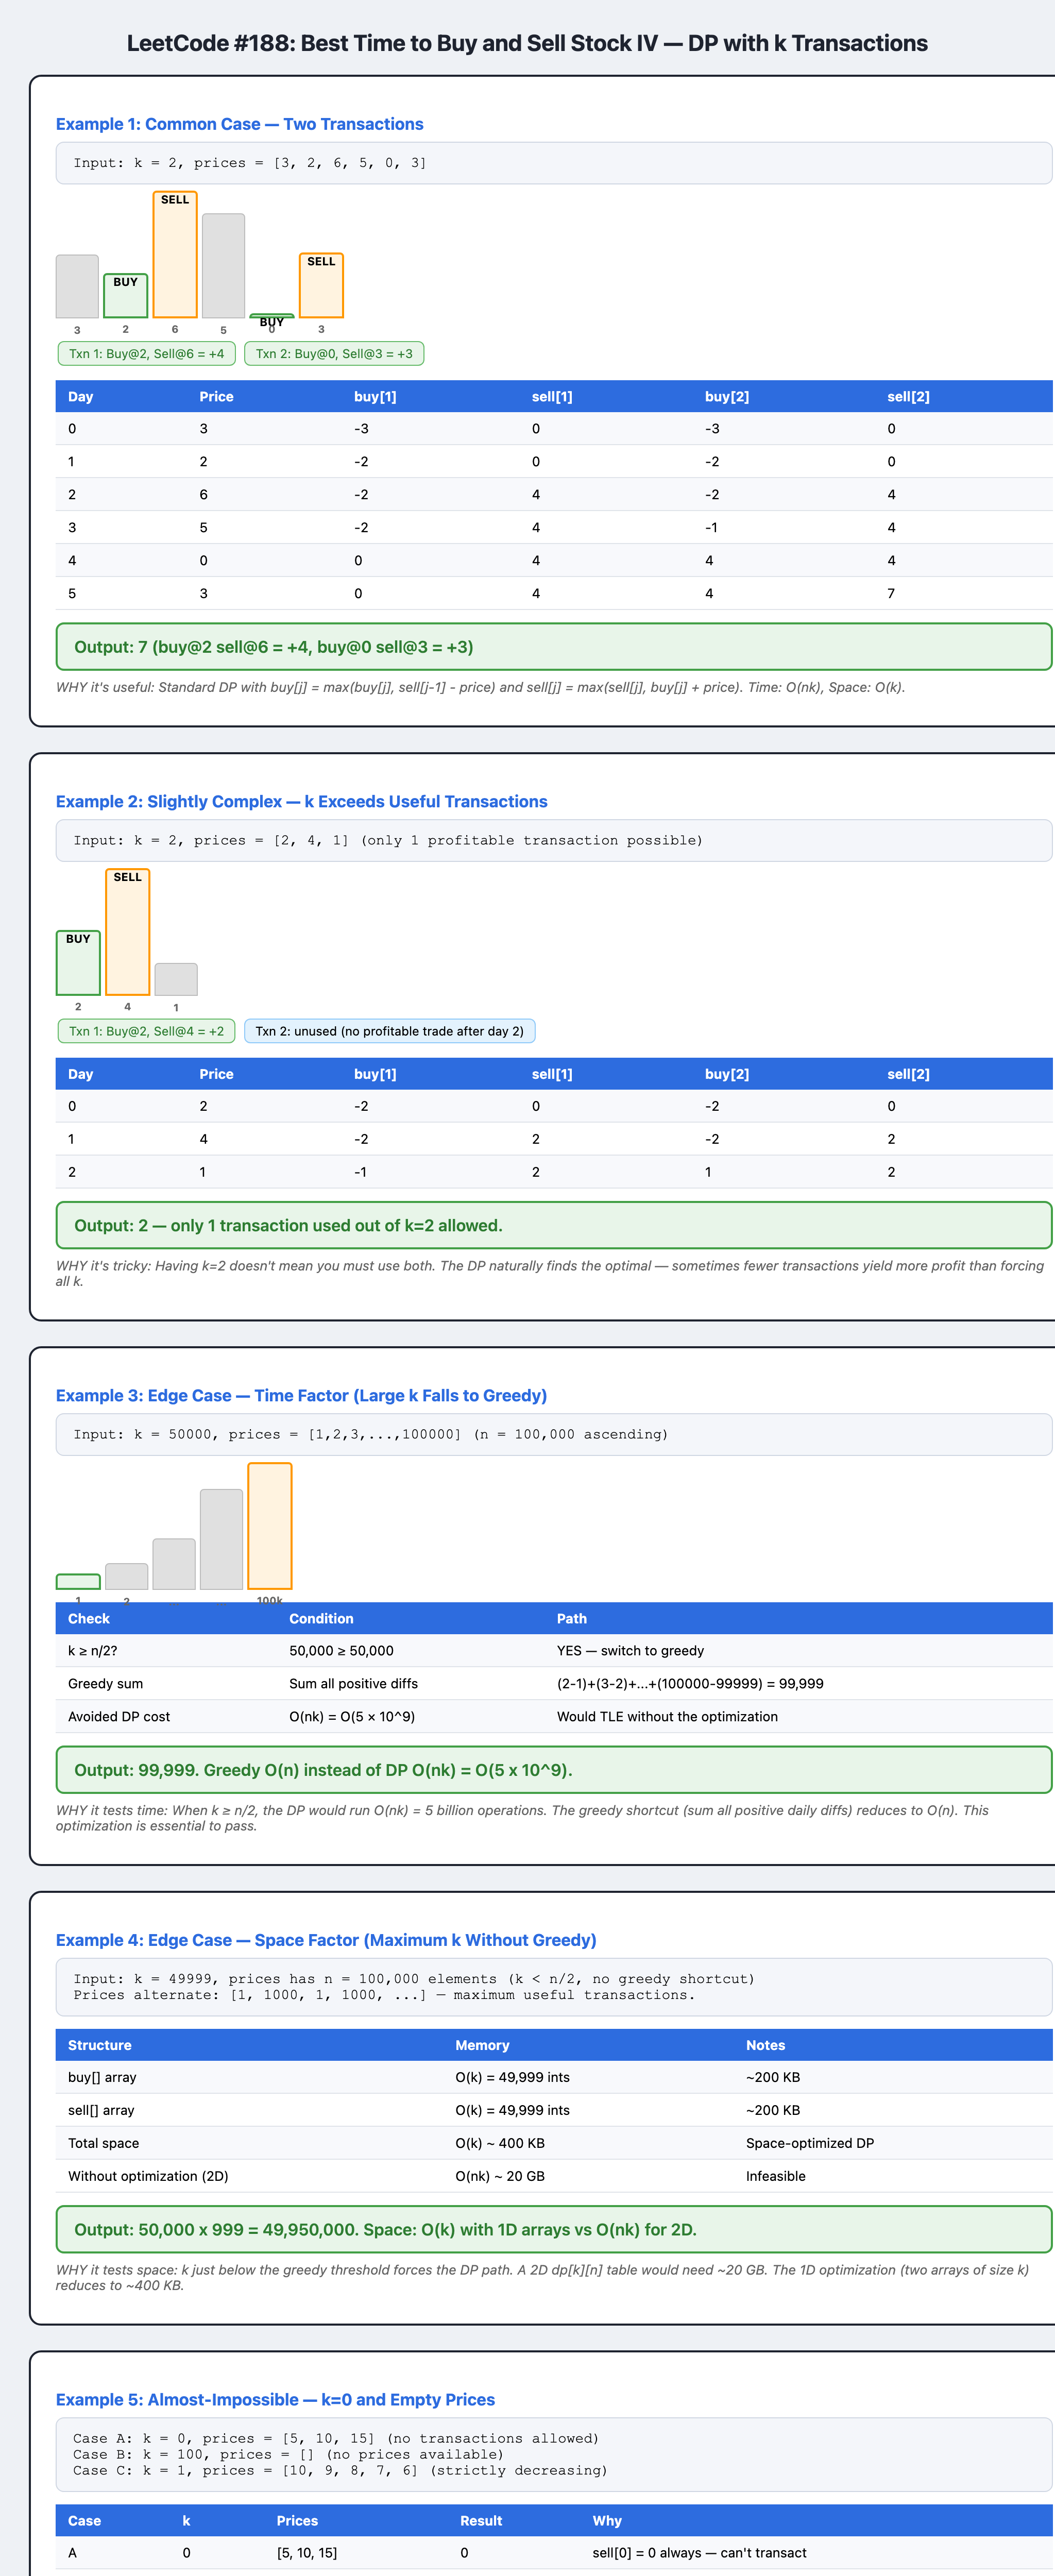